<a href="https://colab.research.google.com/github/ameesha543/Statistical-Learning-e23095/blob/main/Assignment_6/Answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [ ]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [ ]:
import os
import pandas as pd # Added this line
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")

print("Dataset path:", path)
print(os.listdir(path))

df2 = pd.read_csv(path + "/ENB2012_data.csv")

df2.head()

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Dataset path: /kaggle/input/eergy-efficiency-dataset
['ENB2012_data.csv']


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


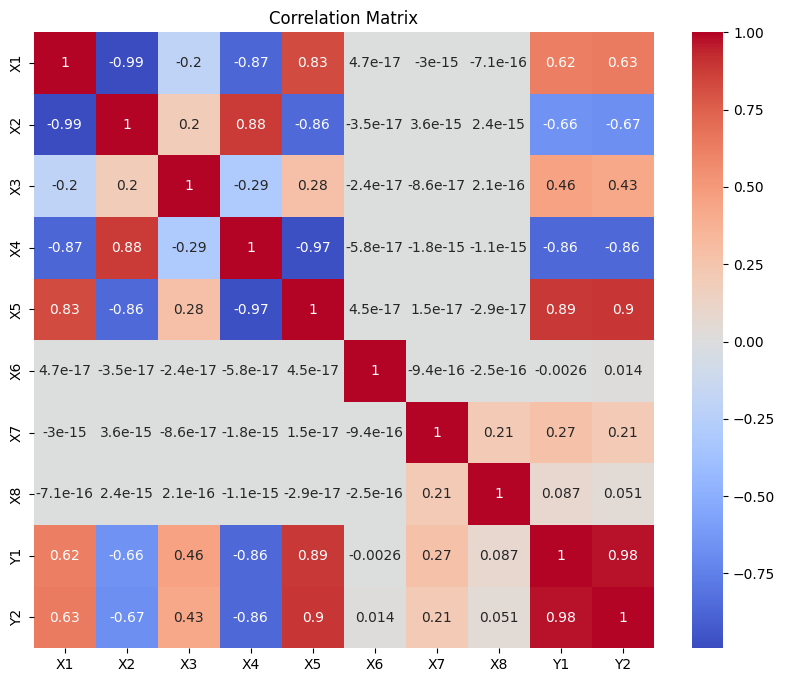

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df2.columns = ['X1','X2','X3','X4','X5','X6','X7','X8','Y1','Y2']

plt.figure(figsize=(10,8))
sns.heatmap(df2.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

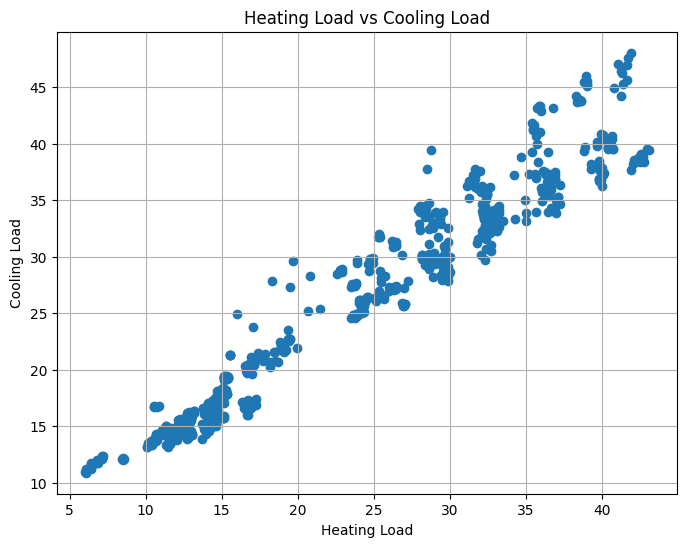

          Y1        Y2
Y1  1.000000  0.975862
Y2  0.975862  1.000000


In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df2['Y1'], df2['Y2'])
plt.xlabel("Heating Load")
plt.ylabel("Cooling Load")
plt.title("Heating Load vs Cooling Load")
plt.grid(True)
plt.show()

print(df2[['Y1','Y2']].corr())

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Y = df2[['Y1','Y2']]

Y_scaled = StandardScaler().fit_transform(Y)

pca = PCA()
pca.fit(Y_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.98793091 0.01206909]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

X = df2[['X1','X2','X3','X4','X5','X6','X7','X8']]

latent_output = pca.transform(Y_scaled)[:,0]

X_train, X_test, y_train, y_test = train_test_split(
    X, latent_output, test_size=0.2, random_state=42
)

kernel = ConstantKernel(1.0) * RBF()

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42
)

gp.fit(X_train, y_train)

print("R² =", gp.score(X_test, y_test))

R² = 0.9860824831888465


Discussion

The relationship between Heating Load ($Y_1$) and Cooling Load ($Y_2$) was investigated using correlation analysis and Principal Component Analysis (PCA). The results showed a strong positive correlation between the two outputs, indicating that they are influenced by similar building characteristics.

PCA revealed that the first principal component explained the majority of the variance in the output data, suggesting that Heating Load and Cooling Load can be represented by a single latent variable. A Gaussian Process model trained on this latent variable achieved good predictive performance, demonstrating that a single-parameter representation captures most of the information contained in the two responses.

Conclusion

The analysis shows that Heating Load and Cooling Load are highly related and can be approximated using a single latent Gaussian Process. While some output-specific information is lost, the single-parameter model provides a compact and effective representation of the building energy performance. Therefore, modeling both responses through a single latent Gaussian Process is a reasonable approach for this dataset.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [ ]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")

Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


In [ ]:
import pandas as pd
import kagglehub

# Download dataset
kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)

# Load csv
df2 = pd.read_csv(path + "/green_building_dataset.csv")

# Display basic information
print(df2.shape)
df2.head()

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
(2400, 19)


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


In [ ]:
df2.isnull().sum()

,0
indoor_temperature,0
indoor_humidity,0
co2_concentration,0
indoor_lighting,0
indoor_noise,0
outdoor_temperature,0
outdoor_humidity,0
solar_radiation,0
wind_speed,0
rainfall,0


In [ ]:
df2 = df2.dropna()

In [ ]:
corr_target = df2.corr(numeric_only=True)['predicted_energy_demand']

corr_target.sort_values(
    ascending=False
)

,predicted_energy_demand
predicted_energy_demand,1.000000
ventilation_rate,0.728865
electricity_consumption,0.398703
cooling_energy,0.370632
heating_energy,0.271304
equipment_load,0.058766
occupancy,0.057655
activity_level,0.018522
wind_speed,0.011333
indoor_humidity,0.007899


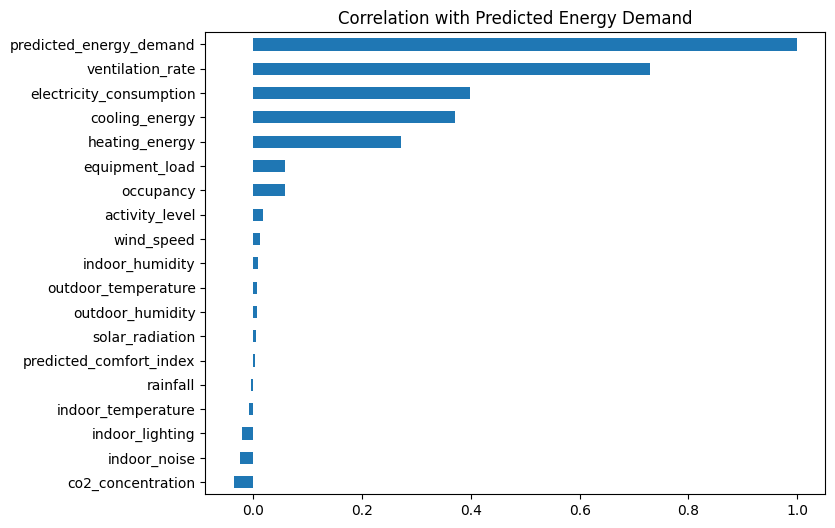

In [ ]:
import matplotlib.pyplot as plt

corr_target.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title('Correlation with Predicted Energy Demand')
plt.show()

In [ ]:
selected_features = [
    'ventilation_rate',
    'electricity_consumption',
    'cooling_energy',
    'heating_energy',
    'occupancy',
    'indoor_temperature',
    'outdoor_temperature'
]

In [ ]:
X = df2[selected_features]

y = df2['predicted_energy_demand']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[23.0245687  51.23569939 21.79220857 23.30781883 30.12016295 39.24207021
 26.06822807 29.92742375 21.83245351 40.40793438]


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)**0.5

print("R² Score =", r2)
print("MAE =", mae)
print("RMSE =", rmse)

R² Score = 0.9539480348156356
MAE = 1.6522212140500172
RMSE = 2.0734718911166223


In [ ]:
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
1,electricity_consumption,0.293298
2,cooling_energy,0.249112
3,heating_energy,0.247481
0,ventilation_rate,0.049730
4,occupancy,0.046945
6,outdoor_temperature,-0.000384
5,indoor_temperature,-0.010094


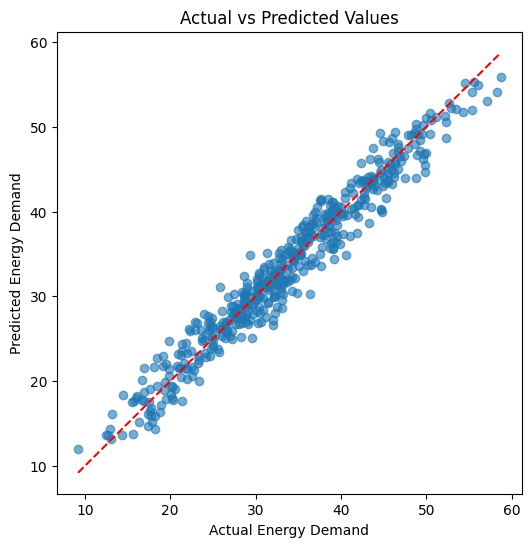

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Energy Demand")
plt.ylabel("Predicted Energy Demand")
plt.title("Actual vs Predicted Values")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

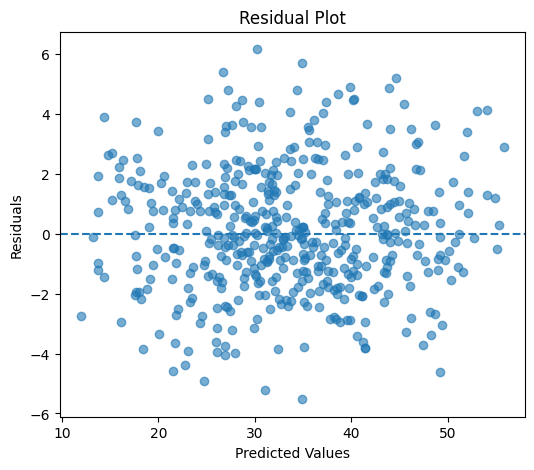

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [ ]:
print("Intercept =", model.intercept_)

for feature, coef in zip(selected_features, model.coef_):
    print(f"{feature}: {coef}")

Intercept = 2.0496259046693375
ventilation_rate: 0.04972993284738033
electricity_consumption: 0.2932980248919581
cooling_energy: 0.24911225499941814
heating_energy: 0.24748088877021152
occupancy: 0.04694469794605584
indoor_temperature: -0.010094310393671533
outdoor_temperature: -0.0003837875010563735


Discussion

A Linear Regression model was developed to predict
\texttt{predicted\_energy\_demand} using ventilation rate,
electricity consumption, cooling energy, and heating energy as input
features. These parameters were selected because they are directly
related to building energy usage and showed strong correlations with
the target variable.

The model achieved an $R^2$ score of 0.9539, indicating that
approximately 95.39\% of the variation in energy demand is explained
by the selected predictors. In addition, the low MAE (1.6522) and
RMSE (2.0735) values indicate that the prediction errors are small.
These results suggest that the selected variables have a strong linear
relationship with energy demand and that Linear Regression is an
effective prediction method for this dataset.

Conclusion

The Linear Regression model successfully predicted building energy
demand with high accuracy, achieving an $R^2$ score of 0.9539. The
results demonstrate that ventilation rate, electricity consumption,
cooling energy, and heating energy are important factors influencing
energy demand. Therefore, Linear Regression provides a simple,
interpretable, and effective approach for predicting energy demand in
green buildings.